\newpage

In [17]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn import neighbors
from sklearn import metrics
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.cluster import KMeans
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [5]:
from ucimlrepo import fetch_ucirepo 

heart_disease = fetch_ucirepo(id=45) 

X = heart_disease.data.features 
y = heart_disease.data.targets 

Q1

In [6]:
df = heart_disease.data.original
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


We are trying to predict our target varibale which is 'num'(the diagnosis of heart disease), so we are going to build a classification model.

Q2

In [7]:
df=df.copy()
df_num = df[['age','trestbps','chol','thalach','oldpeak','ca']]
scale = StandardScaler()
df_std = pd.DataFrame(
    scale.fit_transform(df_num), columns=df_num.columns
    ) 
df_ca=df[['sex','cp','fbs','restecg','exang','slope','thal']]
df_ca_gd = pd.get_dummies(df_ca, columns=df_ca.columns, drop_first=False)
df_transed=pd.concat([df_ca_gd,df_std], axis = 1)

Q3

In [8]:
print(df.shape)
print(heart_disease.variables)

(303, 14)
        name     role         type demographic  \
0        age  Feature      Integer         Age   
1        sex  Feature  Categorical         Sex   
2         cp  Feature  Categorical        None   
3   trestbps  Feature      Integer        None   
4       chol  Feature      Integer        None   
5        fbs  Feature  Categorical        None   
6    restecg  Feature  Categorical        None   
7    thalach  Feature      Integer        None   
8      exang  Feature  Categorical        None   
9    oldpeak  Feature      Integer        None   
10     slope  Feature  Categorical        None   
11        ca  Feature      Integer        None   
12      thal  Feature  Categorical        None   
13       num   Target      Integer        None   

                                          description  units missing_values  
0                                                None  years             no  
1                                                None   None             no  
2    

There are 13 features and 303 observations in the dataset. 'sex','cp','fbs','restecg','exang','slope','thal','num' are categorical variables, 'age','trestbps','chol','thalach','oldpeak','ca' are numerical variables. 'ca' and 'thal' have missing values.

Q4

In [9]:
df_transed['num'] = df['num'].apply(lambda i: 1 if i > 0 else 0)
df_transed['num'] = pd.Categorical(df_transed['num'])
#Github Copilot is used

Q5

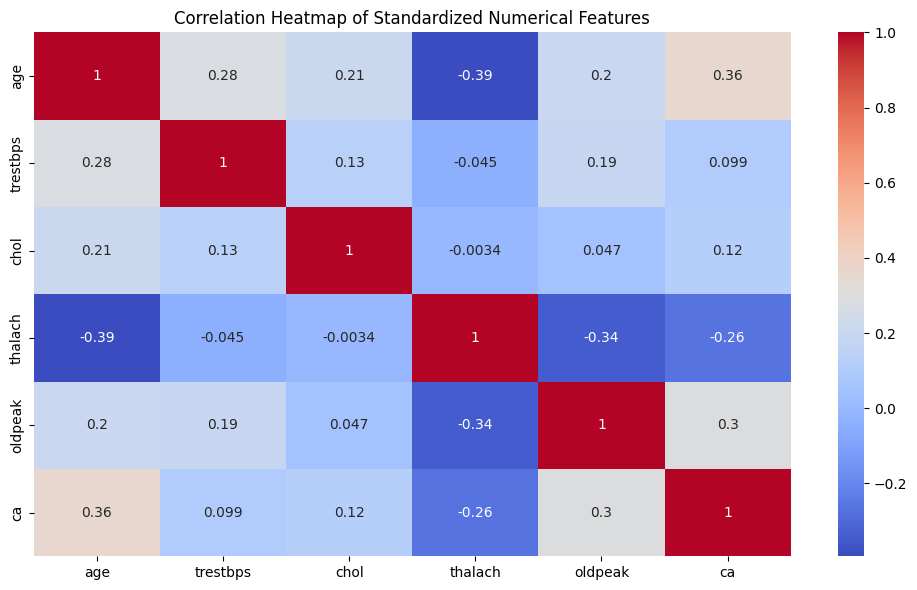

In [ ]:

plt.figure(figsize=(10, 6))
sns.heatmap(df_std.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Standardized Numerical Features")
plt.tight_layout()
plt.show()

From the correlation heatmap, we observe that most numeric features are weakly correlated with each other, with a few exceptions such as 'age' and 'trestbps' (r = 0.28) and a moderate negative correlation between 'age' and 'thalach' (r = -0.39). This suggests a generally low risk of multicollinearity, making these features suitable for direct modeling without redundancy concerns.

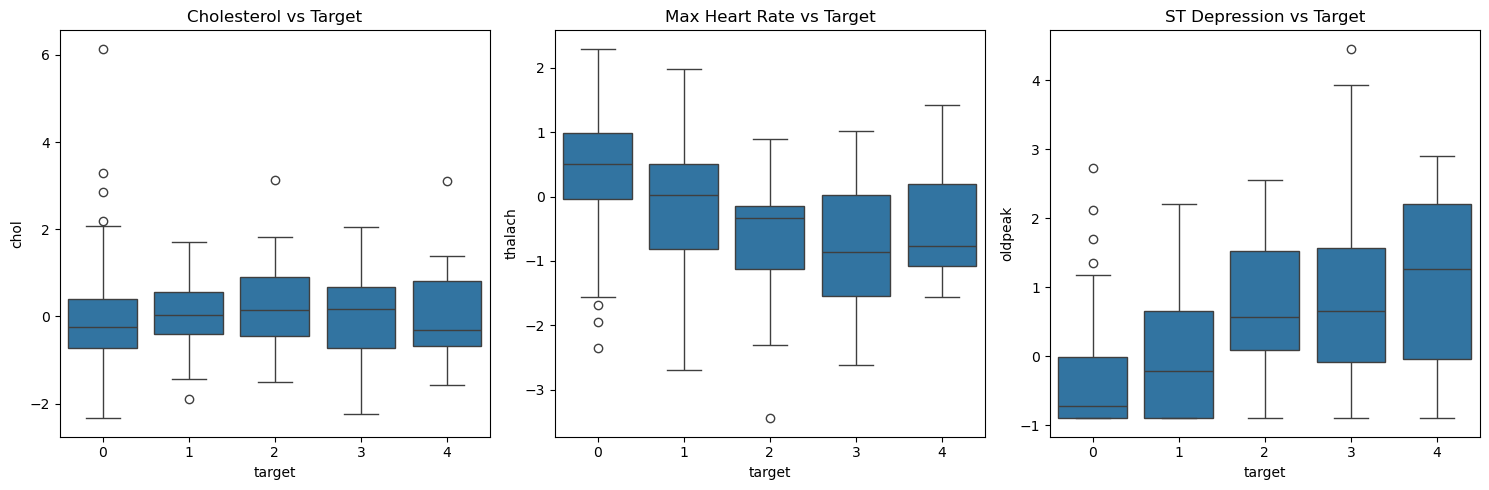

In [ ]:
df_vis = df_std.copy()
df_vis['target'] = y

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(data=df_vis, x="target", y="chol", ax=axes[0])
axes[0].set_title("Cholesterol vs Target")

sns.boxplot(data=df_vis, x="target", y="thalach", ax=axes[1])
axes[1].set_title("Max Heart Rate vs Target")

sns.boxplot(data=df_vis, x="target", y="oldpeak", ax=axes[2])
axes[2].set_title("ST Depression vs Target")

plt.tight_layout()
plt.show()

The boxplots further support these findings: while 'chol' does not vary much across target groups, both 'thalach' and 'oldpeak' demonstrate meaningful separations, especially 'oldpeak', which increases with disease severity.

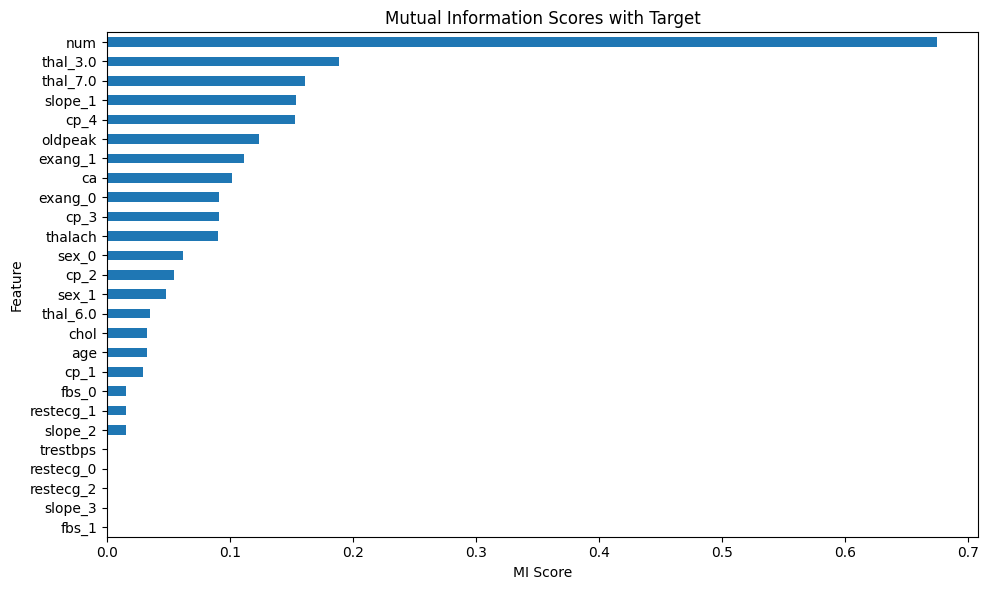

In [18]:
X_mi = df_transed.dropna()
y_mi = y.loc[X_mi.index]

from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_mi, y_mi, discrete_features='auto')
mi_series = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh')
plt.title("Mutual Information Scores with Target")
plt.xlabel("MI Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


The mutual information plot highlights that features like 'ca', 'thal_3.0', and 'cp_4' hold stronger non-linear dependencies with the target. In contrast, features like 'age', 'chol', and 'trestbps' contribute very little information. This implies that during feature selection, these low-scoring variables can be excluded to reduce dimensionality without sacrificing predictive power.

Q6

In [19]:
df_transed=df_transed.dropna()
df_transed.shape

(299, 26)

299 observations after dropping the missing value.

\newpage

## References

Python Data Science Handbook by Jake VanderPlas (O'Reilly Media, Inc., Published on Nov 21, 2016)

Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.